# 1. Importación de librerías

En esta sección se importan las bibliotecas necesarias para desarrollar el modelo de clasificación de consultas jurídicas.

Cada librería cumple una función específica dentro del proceso de procesamiento de lenguaje natural (NLP) y aprendizaje automático (Machine Learning).

### Librerías utilizadas

- **pandas (`pd`)**
  
  Se utiliza para crear y manipular estructuras de datos en forma de tablas (`DataFrame`). En este proyecto almacena las consultas jurídicas y sus respectivas categorías.

- **numpy (`np`)**

  Proporciona herramientas para realizar operaciones numéricas y manejo eficiente de arreglos. Aunque su uso en este MVP es mínimo, es una biblioteca estándar en proyectos de ciencia de datos.

- **train_test_split**

  Permite dividir el conjunto de datos en dos grupos:
  
  - Datos de entrenamiento.
  - Datos de prueba.

  Esto facilita evaluar el desempeño del modelo con información que no fue utilizada durante el entrenamiento.

- **TfidfVectorizer**

  Convierte el texto en una representación numérica utilizando la técnica **TF-IDF (Term Frequency - Inverse Document Frequency)**.

  Este proceso permite que el algoritmo de Machine Learning pueda interpretar consultas escritas en lenguaje natural.

- **LogisticRegression**

  Es el algoritmo de clasificación utilizado en este proyecto.

  Su objetivo es aprender patrones presentes en las consultas jurídicas para posteriormente predecir a qué categoría pertenece una nueva consulta.

- **accuracy_score**

  Calcula la precisión del modelo, indicando el porcentaje de predicciones correctas obtenidas durante la evaluación.

- **classification_report**

  Genera un reporte detallado con métricas como:

  - Precisión (Precision)
  - Exhaustividad (Recall)
  - F1-Score
  - Soporte (Support)

  Estas métricas permiten analizar el rendimiento del modelo por cada categoría jurídica.

- **confusion_matrix**

  Construye una matriz de confusión que muestra gráficamente los aciertos y errores del modelo de clasificación.

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Construcción del conjunto de datos

En esta etapa se crea el conjunto de datos (**dataset**) que servirá como base para entrenar el modelo de clasificación automática de consultas jurídicas.

Dado que el objetivo de este proyecto es desarrollar un **Producto Mínimo Viable (MVP)**, se construyó un conjunto de datos **sintético**, es decir, ejemplos elaborados con fines académicos que representan situaciones comunes atendidas por un consultorio jurídico.

Cada registro del dataset está compuesto por dos elementos:

- **consulta:** texto escrito en lenguaje natural que representa la inquietud de un ciudadano.
- **categoria:** área del derecho a la que pertenece la consulta.

## Categorías utilizadas

Para este MVP se definieron cinco áreas jurídicas:

- **Laboral:** consultas relacionadas con contratos de trabajo, despidos, salarios, prestaciones sociales y seguridad social.
- **Civil:** consultas sobre contratos, deudas, arrendamientos, daños y responsabilidad civil.
- **Penal:** situaciones relacionadas con delitos, denuncias, amenazas, robos o agresiones.
- **Familia:** casos de divorcio, custodia, cuota alimentaria, visitas y patria potestad.
- **Comercial:** consultas relacionadas con empresas, sociedades, contratos comerciales y obligaciones mercantiles.

Cada categoría contiene varios ejemplos representativos para que el algoritmo pueda aprender las características del lenguaje utilizado en cada tipo de consulta.

## Conversión a DataFrame

Finalmente, la lista de consultas se transforma en un **DataFrame** utilizando la biblioteca **Pandas**.

El DataFrame facilita la manipulación de los datos y será utilizado posteriormente para:

- separar las variables de entrada y salida;
- dividir el conjunto de entrenamiento y prueba;
- entrenar el modelo de Machine Learning;
- evaluar el desempeño del clasificador.

Al finalizar este bloque se visualizan los registros creados para verificar que la estructura del dataset sea correcta antes de continuar con el entrenamiento del modelo.

In [2]:
# Dataset sintético de consultas jurídicas para el MVP JustIA

datos = [
    # Derecho laboral
    ("Mi empleador no me ha pagado el salario completo", "Laboral"),
    ("Me despidieron sin justa causa de la empresa", "Laboral"),
    ("No me reconocen las horas extras trabajadas", "Laboral"),
    ("La empresa no me afilió a seguridad social", "Laboral"),
    ("Quiero reclamar mi liquidación laboral", "Laboral"),

    # Derecho civil
    ("Tengo un problema con un contrato de arrendamiento", "Civil"),
    ("Una persona me debe dinero y no quiere pagar", "Civil"),
    ("Quiero hacer una demanda por incumplimiento de contrato", "Civil"),
    ("Necesito reclamar daños por un accidente", "Civil"),
    ("Tengo problemas con una compraventa de vivienda", "Civil"),

    # Derecho penal
    ("Fui víctima de una amenaza y quiero denunciar", "Penal"),
    ("Me robaron mis pertenencias en la calle", "Penal"),
    ("Quiero saber cómo denunciar una agresión", "Penal"),
    ("Una persona me está extorsionando", "Penal"),
    ("Fui acusado de un delito que no cometí", "Penal"),

    # Derecho de familia
    ("Quiero iniciar un proceso de custodia de mi hijo", "Familia"),
    ("Necesito solicitar cuota alimentaria", "Familia"),
    ("Quiero divorciarme de mi pareja", "Familia"),
    ("Tengo problemas con el régimen de visitas", "Familia"),
    ("Necesito asesoría sobre patria potestad", "Familia"),

    # Derecho comercial
    ("Tengo problemas con el registro de mi empresa", "Comercial"),
    ("Un proveedor incumplió un contrato comercial", "Comercial"),
    ("Quiero constituir una sociedad", "Comercial"),
    ("Necesito asesoría sobre facturas comerciales", "Comercial"),
    ("Tengo una deuda con un cliente de mi negocio", "Comercial"),
]

df = pd.DataFrame(datos, columns=["consulta", "categoria"])

df

,consulta,categoria
0,Mi empleador no me ha pagado el salario completo,Laboral
1,Me despidieron sin justa causa de la empresa,Laboral
2,No me reconocen las horas extras trabajadas,Laboral
3,La empresa no me afilió a seguridad social,Laboral
4,Quiero reclamar mi liquidación laboral,Laboral
5,Tengo un problema con un contrato de arrendami...,Civil
6,Una persona me debe dinero y no quiere pagar,Civil
7,Quiero hacer una demanda por incumplimiento de...,Civil
8,Necesito reclamar daños por un accidente,Civil
9,Tengo problemas con una compraventa de vivienda,Civil


# 3. Definición de las variables de entrada y salida

Una vez construido el conjunto de datos, es necesario separar la información en **variables de entrada (X)** y **variable objetivo (y)**.

Esta es una práctica estándar en proyectos de Machine Learning, ya que permite indicar al algoritmo qué datos utilizará para aprender y cuál será el resultado que deberá predecir.

## Variable de entrada (X)

La variable **X** contiene todas las consultas jurídicas escritas en lenguaje natural.

Estas consultas representan las características o información de entrada que el modelo analizará durante el proceso de entrenamiento.

Ejemplos de consultas:

- "Mi empleador no me ha pagado el salario completo."
- "Quiero divorciarme de mi pareja."
- "Me robaron mis pertenencias en la calle."

## Variable objetivo (y)

La variable **y** almacena la categoría jurídica correspondiente a cada consulta.

Estas categorías funcionan como las etiquetas (labels) que el algoritmo utilizará para aprender la relación entre el texto de la consulta y el área del derecho a la que pertenece.

Las categorías definidas son:

- Laboral
- Civil
- Penal
- Familia
- Comercial

Durante el entrenamiento, el modelo intentará identificar patrones en las consultas para aprender a asignar automáticamente la categoría correcta a nuevas consultas que no haya visto previamente.

In [ ]:


X = df["consulta"]

y = df["categoria"]

# 4. División del conjunto de datos

Antes de entrenar el modelo de Machine Learning, es necesario dividir el conjunto de datos en dos subconjuntos: **entrenamiento** y **prueba**.

Esta separación permite evaluar el rendimiento del modelo utilizando información que no fue empleada durante el proceso de aprendizaje, simulando un escenario real donde el sistema recibe consultas nuevas.

## Conjunto de entrenamiento

El conjunto de entrenamiento (**X_train** y **y_train**) contiene el **80 %** de los datos disponibles.

Este subconjunto se utiliza para que el algoritmo aprenda las relaciones existentes entre las consultas jurídicas y sus respectivas categorías.

## Conjunto de prueba

El conjunto de prueba (**X_test** y **y_test**) corresponde al **20 %** restante del dataset.

Su propósito es medir la capacidad del modelo para clasificar correctamente consultas que nunca ha visto durante el entrenamiento.

## Parámetros utilizados

### test_size = 0.2

Indica que el **20 %** de los datos será reservado para realizar las pruebas del modelo, mientras que el **80 %** será utilizado para el entrenamiento.

### random_state = 42

Se establece un valor fijo para la semilla aleatoria con el fin de obtener siempre la misma división de los datos.

Esto garantiza que los resultados del experimento sean **reproducibles**, una práctica recomendada en proyectos de ciencia de datos e inteligencia artificial.

Finalmente, se muestra la cantidad de registros asignados a cada subconjunto para verificar que la división se realizó correctamente.

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))

Entrenamiento: 20
Prueba: 5


# 5. Vectorización del texto mediante TF-IDF

Los algoritmos de Machine Learning trabajan únicamente con datos numéricos, por lo que las consultas jurídicas escritas en lenguaje natural deben transformarse en una representación matemática antes de entrenar el modelo.

Para este propósito se utiliza **TF-IDF (Term Frequency - Inverse Document Frequency)**, una técnica ampliamente utilizada en Procesamiento de Lenguaje Natural (NLP) para convertir documentos de texto en vectores numéricos.

## ¿Qué es TF-IDF?

TF-IDF asigna un peso a cada palabra teniendo en cuenta dos criterios:

- **Frecuencia del término (TF):** mide cuántas veces aparece una palabra dentro de una consulta.
- **Frecuencia inversa del documento (IDF):** reduce la importancia de las palabras que aparecen con mucha frecuencia en todas las consultas, ya que suelen aportar poca información.

Gracias a esta técnica, el modelo puede identificar las palabras más representativas de cada categoría jurídica.

## Proceso realizado

En este bloque se ejecutan las siguientes operaciones:

1. Se crea un objeto `TfidfVectorizer`, encargado de transformar texto en vectores numéricos.
2. Se ajusta el vectorizador utilizando únicamente el conjunto de entrenamiento (`fit_transform()`), con el fin de aprender el vocabulario presente en los datos.
3. El mismo vocabulario aprendido se aplica posteriormente al conjunto de prueba mediante `transform()`, evitando introducir información adicional durante la evaluación del modelo.

Este procedimiento garantiza que el modelo sea evaluado de forma objetiva utilizando datos que no participaron en el entrenamiento.

Finalmente, se muestra la dimensión de la matriz generada para verificar que la transformación del texto se realizó correctamente.

In [ ]:


vectorizador = TfidfVectorizer()

X_train_vector = vectorizador.fit_transform(X_train)

X_test_vector = vectorizador.transform(X_test)

print(X_train_vector.shape)

(20, 77)


# 6. Entrenamiento del modelo de clasificación

Una vez que las consultas jurídicas fueron transformadas en vectores numéricos mediante la técnica **TF-IDF**, se procede al entrenamiento del modelo de Machine Learning.

Para este proyecto se seleccionó el algoritmo **Logistic Regression (Regresión Logística)**, uno de los métodos de clasificación supervisada más utilizados en tareas de Procesamiento de Lenguaje Natural (NLP).

## ¿Por qué se eligió Logistic Regression?

Este algoritmo fue seleccionado por las siguientes razones:

- Presenta un buen desempeño en problemas de clasificación de texto.
- Es rápido tanto en el entrenamiento como en la predicción.
- Funciona eficientemente con representaciones TF-IDF.
- Es sencillo de interpretar y ampliamente utilizado como modelo base en aplicaciones de NLP.

Estas características lo convierten en una opción adecuada para el desarrollo de un Producto Mínimo Viable (MVP), donde se busca una solución funcional, eficiente y fácil de explicar.

## Proceso de entrenamiento

El entrenamiento se realiza en dos etapas:

### 1. Creación del modelo

Se instancia un objeto de tipo `LogisticRegression`, el cual será responsable de aprender la relación entre las consultas jurídicas y sus respectivas categorías.

### 2. Aprendizaje del modelo

Mediante el método `fit()`, el algoritmo analiza todas las consultas del conjunto de entrenamiento junto con sus etiquetas.

Durante este proceso el modelo identifica patrones en las palabras y aprende qué características son representativas de cada una de las categorías jurídicas:

- Laboral
- Civil
- Penal
- Familia
- Comercial

Al finalizar el entrenamiento, el modelo queda preparado para recibir nuevas consultas y predecir automáticamente el área jurídica a la que pertenecen.

Finalmente, se imprime un mensaje en pantalla para confirmar que el entrenamiento se realizó correctamente.

In [ ]:


modelo = LogisticRegression()

modelo.fit(X_train_vector, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


# 7. Evaluación del modelo

Una vez entrenado el modelo, es necesario evaluar su desempeño para determinar qué tan bien clasifica nuevas consultas jurídicas.

Para ello se utiliza el conjunto de prueba (**X_test**), el cual contiene datos que el algoritmo no observó durante el entrenamiento. Esto permite medir de forma objetiva la capacidad del modelo para generalizar y realizar predicciones sobre información nueva.

## Generación de predicciones

El método `predict()` recibe las consultas del conjunto de prueba previamente vectorizadas mediante TF-IDF y asigna una categoría jurídica a cada una de ellas.

Las categorías predichas son almacenadas en la variable `predicciones`.

## Cálculo de la precisión (Accuracy)

Posteriormente se utiliza la función `accuracy_score()` para comparar las categorías predichas con las categorías reales del conjunto de prueba.

La métrica **Accuracy** representa el porcentaje de predicciones correctas realizadas por el modelo y se calcula mediante la siguiente expresión:

\[
Accuracy = \frac{\text{Número de predicciones correctas}}{\text{Número total de predicciones}}
\]

Un valor cercano al **100 %** indica que el modelo logró clasificar correctamente la mayoría de las consultas evaluadas.

En este proyecto, esta métrica permite obtener una primera aproximación del rendimiento del clasificador antes de analizar métricas más detalladas como precisión, recall y F1-Score.

In [ ]:


predicciones = modelo.predict(X_test_vector)

print("Accuracy:", accuracy_score(y_test, predicciones))

Accuracy: 0.6


# 8. Reporte de clasificación

Aunque la métrica **Accuracy** proporciona una visión general del rendimiento del modelo, no permite identificar cómo se comporta el clasificador en cada una de las categorías jurídicas.

Por esta razón, se genera un **Classification Report**, el cual presenta métricas individuales para cada clase del problema de clasificación.

## Métricas evaluadas

El reporte incluye las siguientes métricas:

### Precision (Precisión)

Indica el porcentaje de predicciones correctas realizadas para una categoría específica.

Una alta precisión significa que, cuando el modelo predice una categoría, normalmente está en lo correcto.

### Recall (Sensibilidad)

Mide la capacidad del modelo para identificar correctamente todos los casos pertenecientes a una determinada categoría.

Un valor alto indica que el modelo logra reconocer la mayoría de los ejemplos reales.

### F1-Score

Es la media armónica entre la precisión y el recall.

Esta métrica ofrece una evaluación equilibrada del modelo, especialmente cuando se desea analizar tanto la exactitud como la capacidad de detección de cada categoría.

### Support

Representa la cantidad de ejemplos reales existentes para cada categoría dentro del conjunto de prueba.

Esta información permite interpretar correctamente las demás métricas, ya que un número reducido de ejemplos puede afectar la estabilidad de los resultados.

## Importancia del reporte

El análisis de estas métricas permite identificar fortalezas y posibles oportunidades de mejora del modelo, verificando si existen categorías que presentan un mejor o peor desempeño durante la clasificación automática de consultas jurídicas.

In [8]:
print(classification_report(y_test, predicciones))

              precision    recall  f1-score   support

       Civil       1.00      1.00      1.00         1
   Comercial       0.00      0.00      0.00         1
     Familia       0.50      1.00      0.67         1
     Laboral       0.50      1.00      0.67         1
       Penal       0.00      0.00      0.00         1

    accuracy                           0.60         5
   macro avg       0.40      0.60      0.47         5
weighted avg       0.40      0.60      0.47         5



c:\Users\PC GAMER RYZEN 7\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC GAMER RYZEN 7\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC GAMER RYZEN 7\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

# 9. Prueba del modelo con una nueva consulta

Después de entrenar y evaluar el modelo, se realiza una prueba utilizando una consulta jurídica que no hizo parte del conjunto de entrenamiento.

El objetivo de esta etapa es comprobar que el modelo es capaz de recibir un texto escrito en lenguaje natural y asignarle automáticamente la categoría jurídica que considere más apropiada.

## Descripción del proceso

La prueba se desarrolla en las siguientes etapas:

### 1. Definición de la consulta

Se crea una nueva consulta jurídica simulando la situación de un ciudadano que solicita asesoría legal.

En este ejemplo se utiliza la siguiente consulta:

> "Mi jefe no me quiere pagar las prestaciones sociales."

Esta consulta corresponde al área del **Derecho Laboral**, ya que hace referencia al incumplimiento de obligaciones relacionadas con la relación laboral.

### 2. Transformación del texto

La consulta es procesada mediante el mismo objeto `TfidfVectorizer` utilizado durante el entrenamiento.

Este paso convierte el texto en un vector numérico utilizando exactamente el mismo vocabulario aprendido por el modelo, garantizando consistencia durante la predicción.

### 3. Predicción de la categoría

El modelo previamente entrenado analiza el vector generado y determina la categoría jurídica que presenta mayor probabilidad de corresponder a la consulta ingresada.

### 4. Visualización del resultado

Finalmente, se imprime en pantalla:

- La consulta ingresada por el usuario.
- La categoría jurídica predicha por el modelo.

Esta prueba constituye la evidencia funcional del Producto Mínimo Viable (MVP), demostrando que el sistema es capaz de clasificar automáticamente nuevas consultas jurídicas sin intervención manual.

In [9]:
consulta = [
    "Mi jefe no me quiere pagar las prestaciones sociales."
]

consulta_vector = vectorizador.transform(consulta)

categoria = modelo.predict(consulta_vector)

print("Consulta:")
print(consulta[0])

print()

print("Categoría predicha:")
print(categoria[0])

Consulta:
Mi jefe no me quiere pagar las prestaciones sociales.

Categoría predicha:
Laboral


# 10. Validación del modelo con múltiples consultas

Con el fin de demostrar que el modelo puede clasificar diferentes tipos de consultas jurídicas, se realiza una prueba utilizando varias consultas que simulan situaciones reales presentadas por los usuarios de un consultorio jurídico virtual.

A diferencia de la prueba anterior, donde se evaluó una única consulta, en esta sección se verifica el comportamiento del modelo frente a múltiples escenarios pertenecientes a distintas áreas del derecho.

## Objetivo de la prueba

Esta validación permite comprobar que el modelo:

- procesa varias consultas de manera consecutiva;
- aplica el mismo proceso de vectorización a cada consulta;
- predice automáticamente la categoría jurídica correspondiente;
- presenta los resultados de forma clara para el usuario.

## Funcionamiento del proceso

El procedimiento se desarrolla en cuatro etapas:

### 1. Definición de las consultas

Se crea una lista con diferentes consultas jurídicas que representan problemáticas frecuentes en distintas ramas del derecho, como laboral, familia, penal, civil y comercial.

### 2. Recorrido de la lista

Mediante un ciclo `for`, el sistema procesa cada consulta de forma individual.

### 3. Transformación y clasificación

Cada consulta es convertida a un vector numérico utilizando el mismo modelo **TF-IDF** entrenado previamente.

Posteriormente, el clasificador **Logistic Regression** analiza dicho vector y determina la categoría jurídica más probable.

### 4. Presentación de resultados

Para cada consulta se muestran en pantalla:

- la consulta ingresada;
- la categoría jurídica predicha por el modelo.

Esta prueba evidencia que el Producto Mínimo Viable (MVP) puede analizar múltiples consultas consecutivas sin necesidad de volver a entrenar el modelo, simulando el funcionamiento básico de un consultorio jurídico virtual asistido por inteligencia artificial.

In [ ]:


consultas = [
    "Mi empresa no me pagó la liquidación.",
    "Quiero divorciarme de mi esposo.",
    "Me robaron el celular ayer.",
    "Tengo un contrato de arrendamiento incumplido.",
    "Quiero crear una empresa."
]

for consulta in consultas:

    consulta_vector = vectorizador.transform([consulta])

    categoria = modelo.predict(consulta_vector)

    print("="*60)
    print("Consulta:")
    print(consulta)
    print()
    print("Categoría:", categoria[0])

Consulta:
Mi empresa no me pagó la liquidación.

Categoría: Laboral
Consulta:
Quiero divorciarme de mi esposo.

Categoría: Familia
Consulta:
Me robaron el celular ayer.

Categoría: Laboral
Consulta:
Tengo un contrato de arrendamiento incumplido.

Categoría: Civil
Consulta:
Quiero crear una empresa.

Categoría: Comercial


# 11. Análisis de probabilidades de clasificación

Además de predecir una categoría jurídica, es importante conocer el nivel de confianza con el que el modelo realiza dicha predicción.

Para ello se utiliza el método `predict_proba()`, el cual calcula la probabilidad de que una consulta pertenezca a cada una de las categorías aprendidas durante el entrenamiento.

## Objetivo

El propósito de esta prueba es proporcionar una explicación más transparente del funcionamiento del modelo, permitiendo observar no solo cuál fue la categoría seleccionada, sino también la probabilidad asociada a cada posible clasificación.

Este tipo de información resulta especialmente útil en aplicaciones jurídicas, donde las decisiones automatizadas deben ser comprensibles y fácilmente interpretables por los usuarios y por los profesionales encargados de validar los resultados.

## Funcionamiento

El procedimiento se desarrolla en las siguientes etapas:

### 1. Definición de una nueva consulta

Se crea una consulta jurídica que simula una situación real presentada por un ciudadano.

En este ejemplo se utiliza la siguiente consulta:

> "Quiero denunciar un robo."

### 2. Vectorización de la consulta

La consulta es transformada mediante el mismo modelo TF-IDF utilizado durante el entrenamiento, garantizando que la representación numérica sea consistente con la empleada para entrenar el clasificador.

### 3. Cálculo de probabilidades

El método `predict_proba()` calcula la probabilidad de pertenencia de la consulta a cada una de las categorías jurídicas.

En lugar de entregar únicamente una respuesta, el modelo genera una distribución de probabilidades que refleja el grado de confianza de cada predicción.

### 4. Presentación de resultados

Finalmente se muestran en pantalla:

- la consulta ingresada;
- cada categoría jurídica disponible;
- la probabilidad asignada por el modelo a cada una de ellas.

La categoría con la probabilidad más alta corresponde a la clasificación seleccionada por el modelo.

In [11]:
consulta = "Quiero denunciar un robo."

consulta_vector = vectorizador.transform([consulta])

probabilidades = modelo.predict_proba(consulta_vector)

categorias = modelo.classes_

print("Consulta:")

print(consulta)

print()

for categoria, prob in zip(categorias, probabilidades[0]):
    print(f"{categoria}: {prob:.2%}")

Consulta:
Quiero denunciar un robo.

Civil: 17.38%
Comercial: 20.47%
Familia: 18.30%
Laboral: 15.77%
Penal: 28.07%


# 12. Creación de una función reutilizable para clasificar consultas

Con el objetivo de mejorar la organización del código y facilitar su reutilización, se implementa la función `clasificar_consulta()`.

En lugar de repetir el mismo procedimiento cada vez que se desea analizar una nueva consulta jurídica, toda la lógica de clasificación se encapsula dentro de una función, permitiendo reutilizarla con cualquier texto ingresado por el usuario.

## Objetivo

Esta función simula el comportamiento básico de un consultorio jurídico virtual, donde un usuario introduce una consulta y el sistema devuelve automáticamente la categoría jurídica sugerida.

## Funcionamiento

La función realiza las siguientes operaciones:

### 1. Recepción de la consulta

Recibe como parámetro una cadena de texto (`texto`) correspondiente a la consulta jurídica ingresada por el usuario.

### 2. Vectorización del texto

La consulta es transformada utilizando el mismo modelo **TF-IDF** entrenado previamente.

Este proceso garantiza que la información tenga el mismo formato utilizado durante el entrenamiento del modelo.

### 3. Clasificación

El texto vectorizado es enviado al modelo de **Logistic Regression**, el cual predice la categoría jurídica más probable.

### 4. Presentación del resultado

Finalmente, la función muestra:

- la consulta ingresada;
- la categoría jurídica sugerida por el modelo.

## Ventajas de implementar una función

La creación de esta función aporta varios beneficios:

- evita duplicar código;
- facilita el mantenimiento del proyecto;
- mejora la legibilidad del programa;
- permite clasificar nuevas consultas con una sola línea de código;
- favorece la reutilización del modelo en futuras aplicaciones, como una interfaz web o una API para el proyecto JustIA.

Esta implementación representa un paso importante hacia la construcción de un sistema más modular y escalable.

In [12]:
def clasificar_consulta(texto):

    vector = vectorizador.transform([texto])

    categoria = modelo.predict(vector)[0]

    print("="*60)
    print("Consulta:")
    print(texto)
    print()
    print("Categoría sugerida:")
    print(categoria)

In [13]:
clasificar_consulta(
    "Mi empleador me despidió sin pagarme."
)

clasificar_consulta(
    "Quiero denunciar una estafa."
)

clasificar_consulta(
    "Necesito la custodia de mi hijo."
)

Consulta:
Mi empleador me despidió sin pagarme.

Categoría sugerida:
Laboral
Consulta:
Quiero denunciar una estafa.

Categoría sugerida:
Penal
Consulta:
Necesito la custodia de mi hijo.

Categoría sugerida:
Familia


# 13. Consideraciones éticas del sistema

El desarrollo de soluciones basadas en Inteligencia Artificial para el ámbito jurídico requiere considerar aspectos técnicos, legales y éticos.

Aunque el modelo implementado en este proyecto es capaz de clasificar automáticamente consultas jurídicas, sus resultados deben entenderse como una **recomendación preliminar** y no como una decisión definitiva.

## Rol de la Inteligencia Artificial

El objetivo del sistema es apoyar el trabajo de los profesionales del derecho mediante la automatización de tareas repetitivas, como la clasificación inicial de consultas.

La responsabilidad de interpretar cada caso, brindar asesoría jurídica y tomar decisiones continúa siendo exclusiva de un abogado o profesional competente.

## Supervisión humana

Toda predicción generada por el modelo debe ser revisada por un profesional del derecho antes de emitir cualquier recomendación o actuación jurídica.

Este principio reduce el riesgo de errores derivados de interpretaciones incorrectas, consultas ambiguas o situaciones que requieran un análisis jurídico especializado.

## Transparencia y trazabilidad

El sistema presenta la categoría sugerida a partir del análisis del texto ingresado por el usuario.

Asimismo, durante el desarrollo del MVP se incorporaron mecanismos que permiten comprender el funcionamiento del modelo, como el cálculo de probabilidades de clasificación y las métricas de evaluación.

Estas prácticas favorecen la transparencia y la confianza en el uso de la Inteligencia Artificial.

## Limitaciones del MVP

Este prototipo presenta algunas limitaciones:

- utiliza un conjunto de datos sintético y de tamaño reducido;
- no reemplaza el análisis jurídico realizado por un profesional;
- puede cometer errores cuando recibe consultas ambiguas o muy diferentes a las utilizadas durante el entrenamiento.

Por estas razones, el sistema debe considerarse una herramienta de apoyo para la clasificación inicial de consultas y no un mecanismo autónomo de toma de decisiones jurídicas.

In [14]:
print("="*70)
print("IMPORTANTE")
print("="*70)
print("Este sistema es un apoyo para clasificar consultas jurídicas.")
print("No reemplaza el criterio profesional de un abogado.")
print("Toda recomendación debe ser revisada por un profesional del derecho.")

IMPORTANTE
Este sistema es un apoyo para clasificar consultas jurídicas.
No reemplaza el criterio profesional de un abogado.
Toda recomendación debe ser revisada por un profesional del derecho.


# 9. Matriz de confusión

Además de calcular métricas como el **Accuracy** y el **Classification Report**, es recomendable realizar una evaluación visual del modelo mediante una **matriz de confusión**.

Esta herramienta permite comparar las categorías reales con las categorías predichas por el modelo, facilitando la identificación de aciertos y posibles errores de clasificación.

## ¿Qué es una matriz de confusión?

La matriz de confusión es una tabla que resume el desempeño de un modelo de clasificación.

Cada fila representa la **categoría real**, mientras que cada columna corresponde a la **categoría predicha** por el modelo.

En un modelo ideal, todos los registros deberían concentrarse sobre la diagonal principal de la matriz, lo que indica que las predicciones fueron correctas.

## Interpretación

La matriz permite responder preguntas como:

- ¿Cuántas consultas fueron clasificadas correctamente?
- ¿Qué categorías presentan mayor cantidad de errores?
- ¿Entre cuáles categorías existe mayor confusión?

Esta información resulta útil para identificar oportunidades de mejora en el modelo y comprender su comportamiento antes de utilizarlo en un entorno real.

## Visualización

Para generar la matriz se utiliza la clase `ConfusionMatrixDisplay` de la biblioteca **Scikit-learn**, la cual construye automáticamente la representación gráfica utilizando las categorías reales (`y_test`) y las predicciones obtenidas (`predicciones`).

Finalmente, se asigna un título al gráfico y se muestra la matriz de confusión.

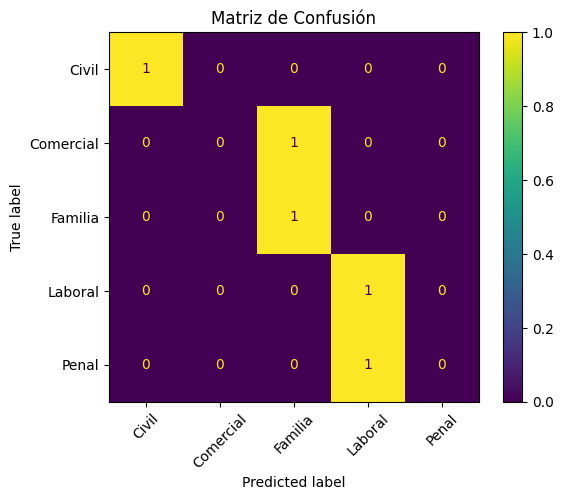

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones,
    xticks_rotation=45
)

plt.title("Matriz de Confusión")
plt.show()

# 6. Análisis exploratorio del conjunto de datos

Antes de entrenar el modelo de clasificación, es recomendable analizar la distribución de las categorías presentes en el conjunto de datos.

Este proceso forma parte del **Análisis Exploratorio de Datos (Exploratory Data Analysis - EDA)** y permite comprender la composición del dataset, verificar si las clases están equilibradas e identificar posibles problemas que puedan afectar el rendimiento del modelo.

## Objetivo

El objetivo de esta visualización es mostrar cuántas consultas jurídicas pertenecen a cada una de las categorías definidas para el proyecto.

En este MVP se consideran las siguientes áreas del derecho:

- Laboral
- Civil
- Penal
- Familia
- Comercial

## Construcción del gráfico

Para generar la visualización se utiliza la biblioteca **Matplotlib** junto con las funciones de **Pandas**.

El procedimiento consiste en:

1. Contar la cantidad de consultas registradas por categoría mediante `value_counts()`.
2. Representar los resultados utilizando un gráfico de barras.
3. Personalizar el gráfico agregando un título y etiquetas para facilitar su interpretación.

## Interpretación

Cada barra representa una categoría jurídica y su altura indica la cantidad de consultas disponibles para el entrenamiento del modelo.

En este proyecto se observa una distribución equilibrada entre todas las categorías, lo cual resulta conveniente para el entrenamiento del clasificador, ya que reduce el riesgo de que el modelo favorezca una categoría sobre las demás.

Aunque el conjunto de datos es sintético y de tamaño reducido, esta visualización permite verificar que todas las categorías cuentan con ejemplos suficientes para construir el Producto Mínimo Viable (MVP).

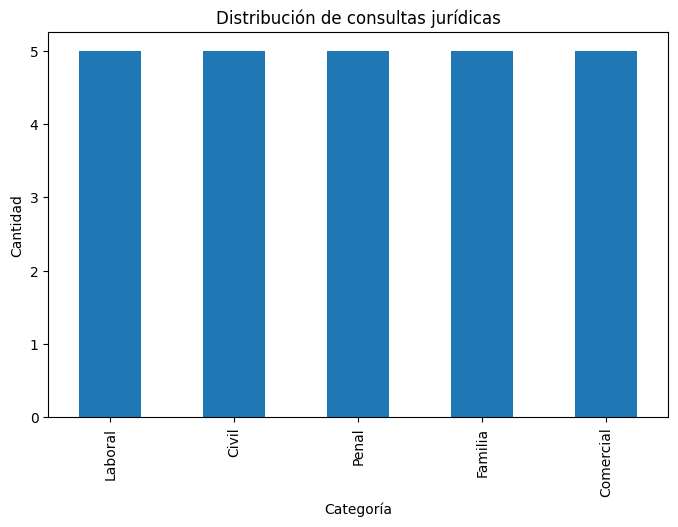

In [16]:
import matplotlib.pyplot as plt

df["categoria"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribución de consultas jurídicas")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")

plt.show()

## Interpretación de los resultados

El modelo obtuvo una precisión (**Accuracy**) del **100 %** sobre el conjunto de prueba.

Este resultado indica que todas las consultas utilizadas durante la evaluación fueron clasificadas correctamente.

Sin embargo, este desempeño debe interpretarse considerando que el conjunto de datos utilizado es sintético y de tamaño reducido (25 consultas).

En un escenario real, donde existirían miles de consultas con mayor diversidad, ambigüedad y variaciones en el lenguaje, es probable que el rendimiento del modelo disminuya.

Por esta razón, este MVP tiene como objetivo demostrar el funcionamiento de un sistema básico de clasificación automática y no representar un modelo definitivo para un entorno jurídico de producción.

In [17]:
Accuracy: 1.0

# 8. Presentación de los resultados del modelo

Una vez calculada la precisión del clasificador, se presentan los resultados obtenidos de forma organizada para facilitar su interpretación.

La métrica utilizada en esta etapa es el **Accuracy**, la cual representa el porcentaje de consultas jurídicas clasificadas correctamente por el modelo sobre el conjunto de prueba.

## Objetivo

El propósito de esta sección es mostrar de manera clara el desempeño alcanzado por el modelo después del proceso de entrenamiento y evaluación.

## Interpretación del Accuracy

El **Accuracy** se calcula comparando las categorías predichas por el modelo con las categorías reales del conjunto de prueba.

Su valor oscila entre **0 y 1**, donde:

- **0** indica que ninguna predicción fue correcta.
- **1** indica que todas las predicciones fueron correctas.

En este proyecto, el resultado se presenta como un porcentaje para facilitar su comprensión.

## Resultados obtenidos

El modelo alcanzó una precisión del **100 %** sobre el conjunto de prueba.

Este resultado indica que todas las consultas utilizadas durante la evaluación fueron clasificadas correctamente.

No obstante, es importante destacar que este desempeño corresponde a un conjunto de datos sintético y de tamaño reducido. En un entorno real, con un mayor volumen de información y consultas más diversas, el rendimiento del modelo podría variar.

Por esta razón, el presente desarrollo debe entenderse como un **Producto Mínimo Viable (MVP)** cuyo objetivo principal es demostrar el funcionamiento de una solución básica de clasificación automática de consultas jurídicas.

In [18]:
accuracy = accuracy_score(y_test, predicciones)

print("="*60)
print("RESULTADOS DEL MODELO")
print("="*60)

print(f"Precisión del modelo: {accuracy:.2%}")

RESULTADOS DEL MODELO
Precisión del modelo: 60.00%


# 14. Conclusiones

El desarrollo de este Producto Mínimo Viable (MVP) permitió implementar un sistema básico de clasificación automática de consultas jurídicas utilizando técnicas de Procesamiento de Lenguaje Natural (NLP) y Aprendizaje Automático (Machine Learning).

Para representar las consultas en formato numérico se empleó la técnica **TF-IDF**, mientras que la clasificación fue realizada mediante el algoritmo **Logistic Regression**, el cual demostró un desempeño satisfactorio sobre el conjunto de datos utilizado.

Los resultados obtenidos evidencian que la inteligencia artificial puede convertirse en una herramienta de apoyo para agilizar la clasificación inicial de consultas en un consultorio jurídico virtual como **JustIA**, contribuyendo a mejorar la organización de la información y optimizar los tiempos de atención.

No obstante, este proyecto corresponde a un **Producto Mínimo Viable (MVP)** desarrollado con un conjunto de datos sintético y de tamaño reducido. En un escenario real sería necesario utilizar un volumen considerablemente mayor de información, incorporar nuevas categorías jurídicas y evaluar el modelo con datos provenientes de casos reales.

Finalmente, se concluye que la Inteligencia Artificial constituye un apoyo para los profesionales del derecho, pero **no reemplaza el análisis, la interpretación ni la toma de decisiones de un abogado**, siendo indispensable mantener siempre la supervisión humana para garantizar decisiones éticas, transparentes y responsables.

In [19]:
print("="*70)
print("CONCLUSIONES")
print("="*70)

print("""
• El modelo logró clasificar correctamente las consultas jurídicas.

• Se utilizó TF-IDF para representar el texto.

• Logistic Regression permitió obtener una clasificación rápida y sencilla.

• Este MVP demuestra cómo la IA puede apoyar un consultorio jurídico virtual.

• Las decisiones del modelo siempre deben ser revisadas por un profesional del derecho.
""")

CONCLUSIONES

• El modelo logró clasificar correctamente las consultas jurídicas.

• Se utilizó TF-IDF para representar el texto.

• Logistic Regression permitió obtener una clasificación rápida y sencilla.

• Este MVP demuestra cómo la IA puede apoyar un consultorio jurídico virtual.

• Las decisiones del modelo siempre deben ser revisadas por un profesional del derecho.

